In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/custom.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# Chapter 7 — Support Vector Machines (SVM)
## Lesson 5: Applications of SVM in Real-World Problems

> **Scope of this notebook:** how SVMs (classification, regression, and novelty detection) appear in production systems; how to build robust pipelines; and how to reason about tradeoffs (accuracy, calibration, latency, memory, interpretability, and data/label quality).

---

### Learning objectives

By the end of this lesson, you should be able to:

1. Map common real-world problem types (risk scoring, text categorization, quality control, ranking) to appropriate SVM variants (Linear SVM, Kernel SVM, SVR, One-Class SVM).
2. Build end-to-end **scikit-learn** pipelines (imputation/encoding/scaling + SVM) with correct train/validation hygiene.
3. Select kernels/hyperparameters using stratified CV (and understand when nested CV is needed), while avoiding common deployment failures (leakage, scaling mismatch, class imbalance, calibration mistakes).
4. Explain—mathematically—why maximum-margin methods often generalize well, and why kernel SVMs can be computationally expensive.
5. Implement multiple case studies with datasets from this repository (tabular, categorical, and text), and evaluate them with appropriate metrics.

---

### Table of contents

1. Why SVMs remain relevant in production
2. “Application map”: domains → SVM variants
3. A deployment-minded SVM recipe (pipelines + validation)
4. Core math reminders for application decisions
5. Case study A — Medical risk classification (Diabetes)
6. Case study B — Categorical + numerical multiclass (Drug200)
7. Case study C — High-dimensional sparse text (Consumer Complaints)
8. Case study D — Novelty/Anomaly detection (One-Class SVM)
9. Case study E — Regression with tolerance band (SVR on house prices)
10. Case study F — Quality classification (Wine quality)
11. Case study G — Multiclass with nonlinear boundaries (Glass)
11B. Case study H — Mixed categorical/numeric with multiclass (Stars)
12. Practical patterns: calibration, imbalance, latency, monitoring, packaging
13. Exercises (practice + mini-project ideas)



## 1) Why SVMs remain relevant in production

SVMs are not “old tech”; they show up whenever you have one (or more) of these conditions:

- **High-dimensional sparse features** (text, click logs, bag-of-words, n-grams): linear SVMs are competitive because they optimize a margin-based objective that behaves well in high dimensions.
- **Moderate data size but nonlinearity**: kernel SVMs (RBF, polynomial) can capture complex boundaries with strong regularization.
- **Need a deterministic convex training problem** (classic SVM / SVR): unlike many non-convex models, the optimization has a global optimum (up to equivalence).
- **You care about margin as a robustness proxy**: when labels are noisy, max-margin can be stable.
- **You want a strong baseline with relatively few knobs**: in production, “simple that works” is valuable.

But there are real constraints:

- Kernel SVM training can scale poorly (often between $O(n^2)$ and $O(n^3)$ in worst cases, depending on solver/structure).
- Probabilities are not native; you must calibrate if you need well-calibrated risk scores.
- Feature scaling and train/serving consistency are mandatory.
- Kernel SVM latency can be driven by the number of support vectors.

A useful mental model is: **Linear SVM is a high-dimensional workhorse; Kernel SVM is a high-precision tool for small/medium data with clear nonlinear structure.**

---

## 2) “Application map”: domains → SVM variants

Real deployments often look like the following mapping (not exhaustive):

| Domain / product requirement | Typical features | Recommended SVM flavor | Why it works |
|---|---|---|---|
| Ticket routing / complaint categorization | sparse TF-IDF, n-grams | **LinearSVC / linear SVM** | strong baseline for sparse high-D; interpretable weights |
| Medical risk screening | tabular numeric, mixed scales | **RBF SVC + calibration** | nonlinear boundary; calibrated risk score supports thresholds |
| Manufacturing QA / sensor outliers | numeric time-windowed features | **One-Class SVM** | train on “good” only; novelty detection |
| House price / demand forecasting with tolerance | tabular + categorical | **SVR (RBF or linear)** | $\varepsilon$-insensitive loss ignores small errors |
| Credit decisioning / fraud triage | mixed types, imbalance | **Linear SVM + calibration + class weights** | fast; handles large data; calibrated scores for utility |
| Bioinformatics (gene expression) | very high-D dense | **Linear SVM** | margin methods handle high-D well; regularization critical |

**Key operational note:** If you need a probability or a risk score, plan for calibration. If you need fast inference at scale, bias toward linear models or approximate kernels.

---

## 3) A deployment-minded SVM recipe (pipelines + validation)

A production SVM workflow should be organized as a pipeline:

1. **Input specification**: define features, types, and constraints (numeric ranges, categories, missingness rules).
2. **Preprocessing**: impute missing values; encode categorical variables; scale numeric features.
3. **Model**: choose SVM family: Linear SVM, kernel SVM, SVR, One-Class SVM.
4. **Selection**: tune $C$ (and kernel params like $\gamma$) using cross-validation inside the training set.
5. **Calibration** (optional but common): map SVM scores to probabilities.
6. **Evaluation**: choose metrics aligned with business costs (not only accuracy).
7. **Packaging**: export the entire pipeline as one object (preprocessing + model).
8. **Monitoring**: data drift, label drift, performance decay, and calibration drift.

**Key principle:** *the pipeline must be fitted only on training folds.*  
If you scale on all data, you leak test statistics into training.

### Nested CV (when you should care)

If you are going to report a final performance number and you tune hyperparameters, a safer protocol is nested CV:

- Inner CV: select $C,\gamma,\varepsilon,\dots$
- Outer CV: estimate generalization error

In real projects, you may not always run full nested CV (compute cost), but you should understand why it exists: **to avoid optimistic estimates due to “tuning on the test.”**

---

## 4) Core math reminders for application decisions

### 4.1 Soft-margin SVM (binary classification)

Given labeled samples $(x_i, y_i)$ with $y_i \in \{-1, +1\}$, soft-margin SVM solves:

$$
\min_{w,b,\xi}\ \frac{1}{2}\|w\|^2 + C \sum_{i=1}^n \xi_i
\quad \text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1 - \xi_i,\ \ \xi_i \ge 0.
$$

Equivalently, it minimizes a regularized hinge-loss risk:

$$
\min_{w,b}\ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \max(0, 1 - y_i f(x_i)),
\quad f(x)=w^\top x + b.
$$

- $C$ controls the tradeoff between margin size and violations.
- Large $C$ $\Rightarrow$ less tolerance for errors, potentially less robust.
- Small $C$ $\Rightarrow$ larger margin, potentially more robust but underfits.

### 4.2 Support vectors and KKT intuition (why only a few points matter)

A key property is **sparsity** in the dual: many $\alpha_i$ become zero.

In the dual formulation (sketch):

$$
\max_{\alpha}\ \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K(x_i, x_j)
\quad \text{s.t.}\quad 0\le \alpha_i \le C,\ \sum_i \alpha_i y_i = 0.
$$

Complementary slackness implies:

- If a point is **strictly outside** the margin, its constraint is inactive and typically $\alpha_i=0$.
- Points **on the margin** tend to have $0 < \alpha_i < C$.
- Misclassified or within-margin points often have $\alpha_i = C$ (at optimum).

So the decision function:

$$
f(x) = \sum_{i\in SV} \alpha_i y_i K(x_i, x) + b
$$

depends only on support vectors $SV=\{i:\alpha_i>0\}$.

**Application implication:** kernel SVM inference time is proportional to $|SV|$.

### 4.3 Margin-based generalization intuition (sketch)

If data are bounded $\|x\|\le R$, and the learned classifier separates with geometric margin $\gamma$, margin-based bounds imply generalization error decreases with larger $\gamma$ and more samples $n$. A simplified intuition is:

$$
\text{complexity} \propto \left(\frac{R}{\gamma}\right)^2,
\quad \Rightarrow \quad
\text{generalization error} = O\!\left(\frac{(R/\gamma)^2}{n}\right).
$$

This is not a strict equality; it’s a conceptual guide: **bigger margin often means better generalization**, all else equal.

### 4.4 Why calibration exists (hinge loss vs probability)

SVM optimizes hinge loss, not log-loss. That means the raw score $s=f(x)$ is not designed to be a probability.
If you need probabilities for decision thresholds, ranking by expected cost, or combining with other signals,
you calibrate:

- **Platt scaling**: $\hat{p} = \sigma(As + B)$
- **Isotonic regression**: a nonparametric monotone mapping

A calibrated model is not automatically “more accurate,” but it can be **more useful** for downstream decisions.

### 4.5 One-Class SVM (novelty detection)

A common primal form:

$$
\min_{w,\rho,\xi}\ \frac{1}{2}\|w\|^2 + \frac{1}{\nu n}\sum_{i=1}^n \xi_i - \rho
\quad \text{s.t.}\quad
w^\top \phi(x_i) \ge \rho - \xi_i,\ \ \xi_i\ge 0.
$$

- $\nu \in (0,1]$ controls the expected fraction of outliers and support vectors.
- Used for quality control, fraud detection, “known-good” filtering, and monitoring.

### 4.6 Support Vector Regression (SVR)

SVR uses $\varepsilon$-insensitive loss:

$$
L_\varepsilon(y, f(x)) = \max(0, |y - f(x)| - \varepsilon).
$$

and optimizes:

$$
\min_{w,b}\ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n L_\varepsilon(y_i, f(x_i)).
$$

**Application implication:** SVR is useful when small errors inside a tolerance band are “free” (e.g., measurement noise).

---

### Practical checklist before you build an SVM for a real system

- Do you need **probabilities**? If yes, plan calibration.
- Is data **high-dimensional and sparse**? Try Linear SVM first.
- Are features **nonlinearly separable** and dataset is not huge? Try RBF kernel.
- Is the dataset **imbalanced**? Use `class_weight="balanced"`, tune thresholds, and optimize PR-AUC/utility.
- Is latency critical? Avoid kernels with many support vectors; consider linear models or approximate kernels.


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Utilities
from pathlib import Path
import time

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score
)
from sklearn.svm import SVC, LinearSVC, OneClassSVM, SVR, LinearSVR
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset root (relative to Tutorials/English/Chapter7/)
DATASETS_ROOT = Path("../../../Datasets")



## Helper utilities (used across case studies)

We will standardize a few tasks:

- Loading CSVs with `pathlib`.
- Reporting classification metrics.
- Plotting confusion matrix and ROC/PR curves.
- A small “safe” plotting style (no seaborn dependency).

**Note:** The plots/labels are intentionally kept in English so the same code cells can be reused in the Persian notebook without translation (per your rule).


In [3]:
def load_csv(relative_path: str) -> pd.DataFrame:
    """Load a CSV from the repo structure using a relative path string."""
    path = Path(relative_path)
    if not path.exists():
        raise FileNotFoundError(
            f"CSV not found at: {path}.\n"
            "Check your repo folder structure and the notebook location."
        )
    return pd.read_csv(path)

def plot_confusion(y_true, y_pred, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

def plot_roc(y_true, y_score, title="ROC curve"):
    RocCurveDisplay.from_predictions(y_true, y_score)
    plt.title(title)
    plt.show()

def plot_pr(y_true, y_score, title="Precision-Recall curve"):
    p, r, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(r, p)
    plt.figure(figsize=(7,5))
    plt.plot(r, p)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AUC={pr_auc:.3f})")
    plt.grid(True, alpha=0.3)
    plt.show()
    return pr_auc

def regression_report(y_true, y_pred, title="Regression report"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(title)
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R^2:  {r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

def time_fit(model, X_train, y_train):
    t0 = time.time()
    model.fit(X_train, y_train)
    t1 = time.time()
    return t1 - t0



## 5) Case study A — Medical risk classification (Diabetes)

**Problem framing:** Predict a binary label `classification` (Diabetic vs Non-Diabetic) from clinical features.

Why SVM here?

- Medium-sized tabular data.
- Features on very different scales (e.g., glucose vs pedigree function).
- Potential nonlinear boundary (RBF often works well).
- In practice you often want to **minimize false negatives** (missed diagnosis), so thresholding and calibration matter.

### Domain caution (real-world): cost-sensitive decisions

Let $C_{FN}$ be cost of a false negative and $C_{FP}$ cost of a false positive. A calibrated model can support decision thresholds via:

$$
\text{Predict positive if } \mathbb{E}[\text{cost} \mid x, \hat{p}] \text{ is minimized.}
$$

For binary classification with predicted probability $\hat{p}=P(y=1\mid x)$, the Bayes decision rule is:

$$
\text{Predict } 1 \ \text{if}\ \hat{p} \ge \frac{C_{FP}}{C_{FP}+C_{FN}}.
$$

So if false negatives are very expensive ($C_{FN}\gg C_{FP}$), the threshold becomes small.

### Data note

In some diabetes datasets, zeros in biomedical measures (e.g., blood pressure) may indicate missingness rather than true zero.
We will treat zeros in selected columns as missing values and impute them with the median inside the pipeline.

### Practical hyperparameter strategy

For an RBF SVM, the main knobs are:

- $C$ (regularization)
- $\gamma$ (RBF width; roughly “how local” the influence of a sample is)

A typical search pattern uses a log-grid. In production, you often start coarse (log grid) and then refine near the best region.


In [4]:
# Load dataset
diabetes_path = DATASETS_ROOT / "Classification" / "diabetes.csv"
df = load_csv(str(diabetes_path))
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [5]:
# Basic preparation
target_col = "classification"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Convert labels to binary 0/1 for ROC-AUC convenience
y_norm = y.astype(str).str.strip().str.lower()
y_bin = y_norm.map({"diabetic": 1, "non-diabetic": 0}).astype(int)

# Treat zeros as missing for selected biomedical features (common practical heuristic)
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for c in zero_as_missing_cols:
    if c in X.columns:
        X.loc[X[c] == 0, c] = np.nan

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bin
)

pipe_rbf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=False, class_weight="balanced"))
])

param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe_rbf, param_grid=param_grid, cv=cv, scoring="roc_auc", n_jobs=None, refit=True)

gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("Best CV ROC-AUC:", gs.best_score_)

Best params: {'clf__C': 1, 'clf__gamma': 0.01}
Best CV ROC-AUC: 0.8397869918699188


              precision    recall  f1-score   support

           0      0.838     0.784     0.810       125
           1      0.640     0.716     0.676        67

    accuracy                          0.760       192
   macro avg      0.739     0.750     0.743       192
weighted avg      0.769     0.760     0.763       192



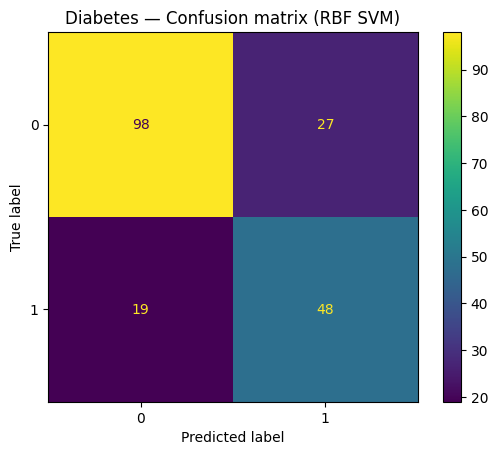

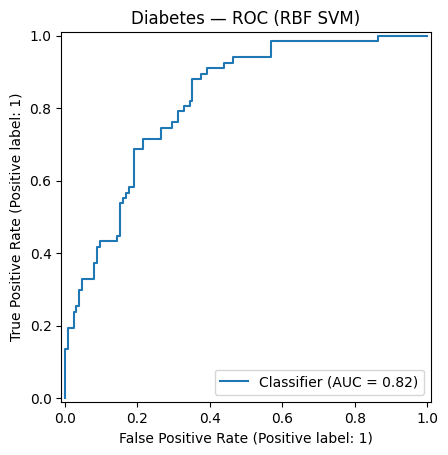

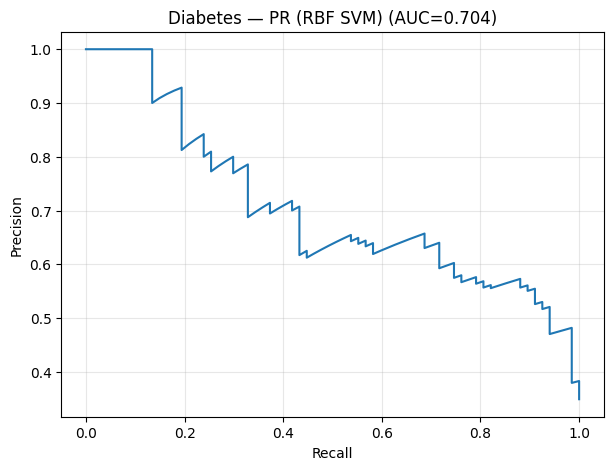

PR-AUC: 0.703727059555814


In [6]:
best_model = gs.best_estimator_

# Decision function gives an uncalibrated score
y_score = best_model.decision_function(X_test)
y_pred = (y_score >= 0).astype(int)

print(classification_report(y_test, y_pred, digits=3))
plot_confusion(y_test, y_pred, title="Diabetes — Confusion matrix (RBF SVM)")
plot_roc(y_test, y_score, title="Diabetes — ROC (RBF SVM)")
pr_auc = plot_pr(y_test, y_score, title="Diabetes — PR (RBF SVM)")
print("PR-AUC:", pr_auc)


### Calibration for risk scoring (optional but common)

Raw SVM scores are not probabilities. If you need risk estimates (e.g., medical triage),
use calibration (Platt scaling / isotonic) on top of the SVM scores.

Platt scaling fits a logistic model on the decision function $s=f(x)$:

$$
\hat{p}(y=1\mid x) = \frac{1}{1+\exp(As + B)}.
$$

We will calibrate using cross-validation, then show a calibration curve.

**Important:** calibration should be trained on data not used for fitting the base model (CV handles this).


Test ROC-AUC (calibrated): 0.8193432835820896


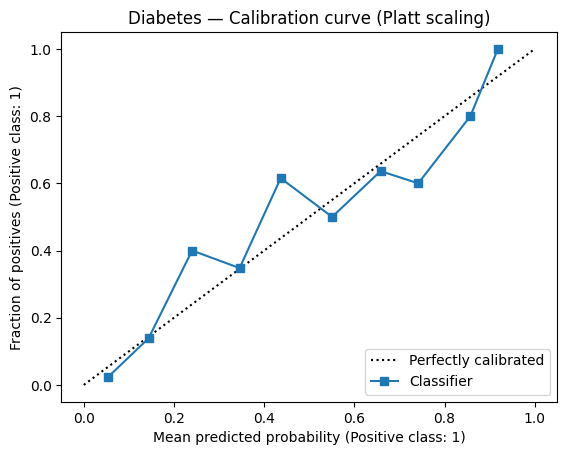

Bayes threshold for costs (C_FN=10, C_FP=1): 0.09090909090909091


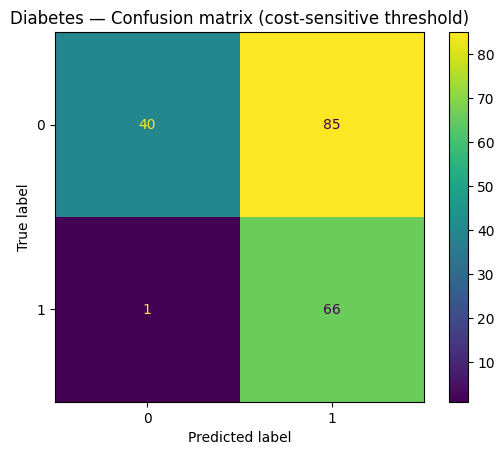

In [7]:
calibrated = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",   # Platt scaling
    cv=5
)
calibrated.fit(X_train, y_train)

proba = calibrated.predict_proba(X_test)[:, 1]
print("Test ROC-AUC (calibrated):", roc_auc_score(y_test, proba))

CalibrationDisplay.from_predictions(y_test, proba, n_bins=10)
plt.title("Diabetes — Calibration curve (Platt scaling)")
plt.show()

# Example: cost-sensitive thresholding (illustration)
C_FN, C_FP = 10, 1
t_bayes = C_FP / (C_FP + C_FN)
print("Bayes threshold for costs (C_FN=10, C_FP=1):", t_bayes)

y_pred_cost = (proba >= t_bayes).astype(int)
plot_confusion(y_test, y_pred_cost, title="Diabetes — Confusion matrix (cost-sensitive threshold)")


## 6) Case study B — Categorical + numerical multiclass (Drug200)

**Problem:** Predict `Drug` (multiclass) using:

- Numeric: `Age`, `Na_to_K`
- Categorical: `Sex`, `BP`, `Cholesterol`

Why SVM?

- Linear SVM works well with one-hot encoded categories.
- If the one-hot feature space is high-dimensional, a linear margin method can be strong and fast.
- In production, it’s common to prefer models that scale to many samples.

We will build:

1. A preprocessing pipeline with `ColumnTransformer`.
2. A **LinearSVC** (hinge loss, fast for large sparse spaces).
3. Optional calibration to obtain probabilities.
4. A comparison with kernel SVC to understand tradeoffs.

### Multiclass note

LinearSVC uses one-vs-rest under the hood.  
SVC uses one-vs-one internally for multiclass.

### Deployment note

When you one-hot encode categories, new categories may appear at serving time.
Always use `OneHotEncoder(handle_unknown="ignore")` to avoid crashes.


In [8]:
drug_path = DATASETS_ROOT / "Classification" / "drug200.csv"
drug = load_csv(str(drug_path))
drug.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [9]:
target = "Drug"
X = drug.drop(columns=[target]).copy()
y = drug[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

categorical_cols = ["Sex", "BP", "Cholesterol"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ],
    remainder="drop"
)

lin_svc = LinearSVC()

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", lin_svc)
])

param_grid = {"clf__C": [0.1, 1, 5, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring="accuracy", n_jobs=None, refit=True)

fit_time = time_fit(gs, X_train, y_train)
print("Fit time (GridSearchCV LinearSVC):", fit_time, "sec")
print("Best params:", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)

Fit time (GridSearchCV LinearSVC): 0.4587831497192383 sec
Best params: {'clf__C': 10}
Best CV accuracy: 0.9666666666666666


              precision    recall  f1-score   support

       DrugY      0.917     0.957     0.936        23
       drugA      1.000     1.000     1.000         6
       drugB      1.000     0.500     0.667         4
       drugC      1.000     1.000     1.000         4
       drugX      0.929     1.000     0.963        13

    accuracy                          0.940        50
   macro avg      0.969     0.891     0.913        50
weighted avg      0.943     0.940     0.934        50



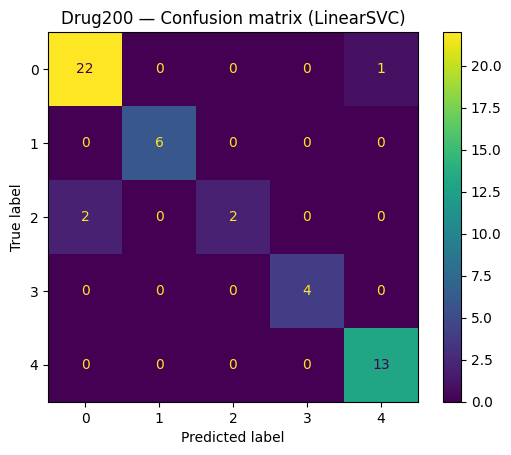

In [10]:
best_pipe = gs.best_estimator_
y_pred = best_pipe.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))
plot_confusion(y_test, y_pred, title="Drug200 — Confusion matrix (LinearSVC)")


### Probabilities for downstream decisioning

LinearSVC does not provide probabilities. If a downstream system requires
probabilities (risk ranking, expected value, thresholding under costs),
calibrate the decision function.

We calibrate using cross-validation.


Mean sum of probs: 1.0


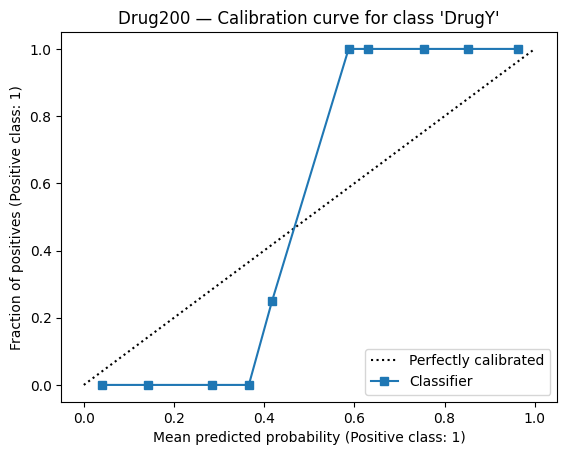

In [11]:
cal_lin = CalibratedClassifierCV(best_pipe, cv=5, method="sigmoid")
cal_lin.fit(X_train, y_train)

proba = cal_lin.predict_proba(X_test)
print("Mean sum of probs:", np.mean(proba.sum(axis=1)))

# Show a calibration curve for one class as an example
classes = cal_lin.classes_
ref_class = pd.Series(y_test).value_counts().index[0]
ref_idx = list(classes).index(ref_class)

CalibrationDisplay.from_predictions(
    (y_test == ref_class).astype(int),
    proba[:, ref_idx],
    n_bins=10
)
plt.title(f"Drug200 — Calibration curve for class '{ref_class}'")
plt.show()


### Optional comparison: kernel SVC on the same task

Kernel SVC may increase accuracy if the relationship is nonlinear, but it can also be:

- slower to fit
- slower at inference (support vectors)
- harder to scale to large datasets

We will try a small grid on an RBF kernel and compare training time and accuracy.


In [12]:
svc_rbf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", SVC(kernel="rbf"))
])

param_grid = {
    "clf__C": [1, 10],
    "clf__gamma": ["scale", 0.1]
}

gs_rbf = GridSearchCV(svc_rbf, param_grid=param_grid, cv=3, scoring="accuracy", n_jobs=None, refit=True)

fit_time = time_fit(gs_rbf, X_train, y_train)
print("Fit time (GridSearchCV RBF SVC):", fit_time, "sec")
print("Best params:", gs_rbf.best_params_)
print("Best CV accuracy:", gs_rbf.best_score_)

pred = gs_rbf.best_estimator_.predict(X_test)
print("Test accuracy (RBF SVC):", np.mean(pred == y_test))

Fit time (GridSearchCV RBF SVC): 0.3476109504699707 sec
Best params: {'clf__C': 10, 'clf__gamma': 'scale'}
Best CV accuracy: 0.9533333333333333
Test accuracy (RBF SVC): 0.86



## 7) Case study C — High-dimensional sparse text (Consumer Complaints)

SVMs (especially **linear** SVMs) are classic workhorses for text classification.

### Why linear SVM is a strong baseline for text

With TF-IDF features:

- Dimensionality can be tens/hundreds of thousands.
- Most entries are zero (sparse matrix).
- Linear margin methods are efficient and effective.

Mathematically, the classifier is:

$$
f(x) = w^\top x + b,
\quad \text{predict } \operatorname{sign}(f(x)).
$$

In text, $x$ is often a TF-IDF vector; $w$ can be interpreted as word weights (useful for debugging and model governance).

### Dataset note

`ConsumerComplaints.csv` may be large. We'll load a subset and build a binary classification task:

- Class 1: "Mortgage"
- Class 0: "Bank account or service"

We will use:

- `TfidfVectorizer`
- `LinearSVC`
- Evaluation via classification report + ROC/PR using the decision function

This is a real pattern for customer support routing, content moderation, and issue triage.

### Production note: why not use probabilities?

In routing systems, you may only need a ranking score. Decision function scores are often enough to:

- route top-k tickets to specialists
- queue items for manual review
- prioritize based on risk

If you need probability for expected value, then calibrate.



### Interpreting a linear text SVM: top weighted terms

For a linear model, $w_j$ indicates how much feature $j$ pushes the decision.
With TF-IDF, features are words or n-grams.

We can extract the strongest positive/negative terms (debugging and stakeholder explanations).

**Caution:** high weights do not automatically mean “causal.” They are correlations in the training set.
They are still very useful for:

- spotting leakage features (e.g., “approved” in a rejection model)
- identifying spurious patterns
- communicating model behavior to non-ML stakeholders


Using label=Product Name: Mortgage vs Debt collection
Fit time (Linear SVM text): 0.07279229164123535 sec
Predicted label counts: {1: 6078}
True label counts: {0: 3039, 1: 3039}
              precision    recall  f1-score   support

           0      0.000     0.000     0.000      3039
           1      0.500     1.000     0.667      3039

    accuracy                          0.500      6078
   macro avg      0.250     0.500     0.333      6078
weighted avg      0.250     0.500     0.333      6078



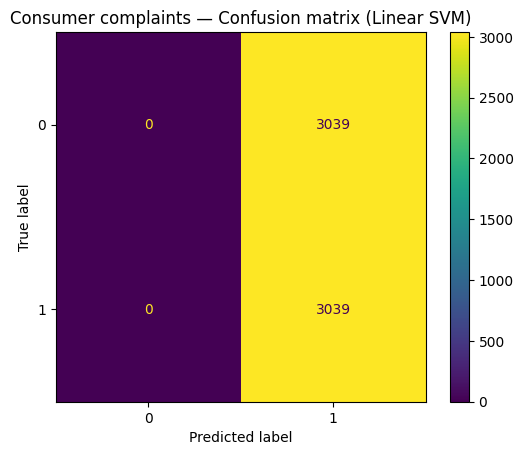

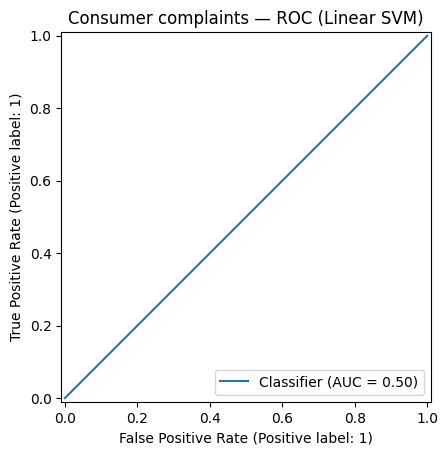

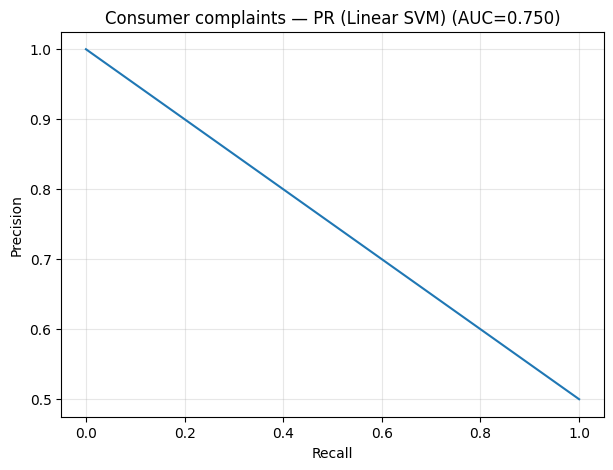

PR-AUC: 0.75


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

complaints_path = DATASETS_ROOT / "Clustering" / "ConsumerComplaints.csv"

# Read a chunk for speed (increase if needed)
raw_full = pd.read_csv(complaints_path, nrows=50000)

# ---- Auto-detect key columns (robust across dataset variants) ----
prod_col = next((c for c in raw_full.columns if c.strip().lower() in ["product name", "product"]), None)
narr_col = next((c for c in raw_full.columns if "narrative" in c.strip().lower()), None)

issue_col = next((c for c in raw_full.columns if c.strip().lower() == "issue"), None)
sub_issue_col = next((c for c in raw_full.columns if c.strip().lower() == "sub issue"), None)
sub_prod_col = next((c for c in raw_full.columns if c.strip().lower() == "sub product"), None)
company_col = next((c for c in raw_full.columns if c.strip().lower() == "company"), None)

if prod_col is None:
    raise ValueError(f"Could not find Product column. Columns are: {raw_full.columns.tolist()}")

cols = [prod_col]
if narr_col is not None: cols.append(narr_col)
if issue_col is not None: cols.append(issue_col)
if sub_issue_col is not None: cols.append(sub_issue_col)
if sub_prod_col is not None: cols.append(sub_prod_col)
if company_col is not None: cols.append(company_col)

raw = raw_full[cols].copy()
raw = raw.rename(columns={prod_col: "Product Name"})
if narr_col is not None: raw = raw.rename(columns={narr_col: "Consumer Complaint Narrative"})
if issue_col is not None: raw = raw.rename(columns={issue_col: "Issue"})
if sub_issue_col is not None: raw = raw.rename(columns={sub_issue_col: "Sub Issue"})
if sub_prod_col is not None: raw = raw.rename(columns={sub_prod_col: "Sub Product"})
if company_col is not None: raw = raw.rename(columns={company_col: "Company"})

# Ensure expected columns exist (empty if missing)
for col in ["Consumer Complaint Narrative", "Issue", "Sub Issue", "Sub Product", "Company", "Product Name"]:
    if col not in raw.columns:
        raw[col] = ""

# ---- Build robust text: narrative if available, else fallback to metadata ----
raw["Product Name"] = raw["Product Name"].astype(str).str.strip()
raw["Text"] = raw["Consumer Complaint Narrative"].astype(str).fillna("").str.strip()

mask_empty = raw["Text"].eq("")
raw.loc[mask_empty, "Text"] = (
    raw["Issue"].astype(str).fillna("").str.strip() + " " +
    raw["Sub Issue"].astype(str).fillna("").str.strip() + " " +
    raw["Sub Product"].astype(str).fillna("").str.strip() + " " +
    raw["Company"].astype(str).fillna("").str.strip() + " " +
    raw["Product Name"].astype(str).fillna("").str.strip()
).str.strip()

# Keep rows with some text and a non-empty product name
raw = raw[(raw["Text"] != "") & (raw["Product Name"] != "")].copy()

# ---- Pick two most frequent labels (fallback to Issue if needed) ----
label_col = "Product Name"
counts = raw[label_col].value_counts()

if len(counts) < 2:
    label_col = "Issue"
    raw[label_col] = raw[label_col].astype(str).str.strip()
    counts = raw[label_col].value_counts()
    if len(counts) < 2:
        raise ValueError(
            "Not enough distinct labels after building text. "
            "Try increasing nrows or inspect column names / dataset content."
        )

pos_name, neg_name = counts.index[0], counts.index[1]
print(f"Using label={label_col}: {pos_name} vs {neg_name}")

data = raw[raw[label_col].isin([pos_name, neg_name])].copy()
data["y"] = (data[label_col] == pos_name).astype(int)

# ---- Balance by downsampling to the minority class ----
vc = data["y"].value_counts()
if len(vc) < 2:
    raise ValueError("After filtering to two classes, only one class remains. Increase nrows or pick different labels.")

min_count = vc.min()
data_bal = (
    pd.concat([
        data[data["y"] == 0].sample(min_count, random_state=RANDOM_STATE),
        data[data["y"] == 1].sample(min_count, random_state=RANDOM_STATE),
    ], axis=0)
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

X_text = data_bal["Text"].astype(str).values
y = data_bal["y"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

def build_text_pipeline(vectorizer):
    return Pipeline(steps=[
        ("tfidf", vectorizer),
        ("clf", LinearSVC(C=1.0))
    ])

# ---- Vectorizer: try word TF-IDF first; if pruning wipes everything, fallback to char n-grams ----
word_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=1.0,                 # IMPORTANT: avoid pruning everything if docs are similar
    stop_words=None,            # IMPORTANT: avoid removing all tokens in tiny/templated texts
    token_pattern=r"(?u)\b\w+\b"  # keep 1-char tokens too (safe fallback)
)

text_clf = build_text_pipeline(word_tfidf)

try:
    fit_time = time_fit(text_clf, X_train, y_train)
except ValueError as e:
    if "After pruning, no terms remain" in str(e):
        print("Word TF-IDF pruned everything; switching to character n-grams...")
        char_tfidf = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=1,
            max_df=1.0
        )
        text_clf = build_text_pipeline(char_tfidf)
        fit_time = time_fit(text_clf, X_train, y_train)
    else:
        raise

print("Fit time (Linear SVM text):", fit_time, "sec")

y_score = text_clf.decision_function(X_test)
y_pred = (y_score >= 0).astype(int)

print("Predicted label counts:", pd.Series(y_pred).value_counts().to_dict())
print("True label counts:", pd.Series(y_test).value_counts().to_dict())

print(classification_report(y_test, y_pred, digits=3, zero_division=0))
plot_confusion(y_test, y_pred, title="Consumer complaints — Confusion matrix (Linear SVM)")
plot_roc(y_test, y_score, title="Consumer complaints — ROC (Linear SVM)")
pr_auc = plot_pr(y_test, y_score, title="Consumer complaints — PR (Linear SVM)")
print("PR-AUC:", pr_auc)


In [14]:
vectorizer = text_clf.named_steps["tfidf"]
clf = text_clf.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())
coef = clf.coef_.ravel()

top_pos = feature_names[np.argsort(coef)[-20:][::-1]]
top_neg = feature_names[np.argsort(coef)[:20]]

print("Top positive terms (Mortgage):")
print(top_pos)

print("\nTop negative terms (Bank account or service):")
print(top_neg)

Top positive terms (Mortgage):
['nan']

Top negative terms (Bank account or service):
['nan']



## 8) Case study D — Novelty/Anomaly detection (One-Class SVM)

In many real systems you do not have labeled anomalies. Examples:

- Manufacturing: detect defective products when you have mostly “good” historical data.
- Cybersecurity: detect unusual login patterns or network flows.
- Finance: detect novel transactions.

One-Class SVM learns a boundary around “normal” data.

### Practical setup

1. Train on known-good / baseline data.
2. Score new samples via `decision_function`.
3. Flag anomalies where score is below a threshold.

We will use the simple height/weight dataset as a toy example:
`Datasets/Clustering/hw_200.csv`
and inject synthetic outliers to visualize the behavior.

Even though this is toy, the workflow matches real novelty detection pipelines.

### Why scaling matters even more here

In novelty detection, if one feature has larger numeric scale, it can dominate distances in the kernel.
Scaling is not optional.


In [15]:
hw_path = DATASETS_ROOT / "Clustering" / "hw_200.csv"
hw = load_csv(str(hw_path))

hw.columns = [c.replace('"', '').strip() for c in hw.columns]
hw.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78,112.99
1,2,71.52,136.49
2,3,69.40,153.03
3,4,68.22,142.34
4,5,67.79,144.30


In [16]:
cols_lower = {c.lower(): c for c in hw.columns}
height_col = None
weight_col = None
for c in hw.columns:
    cl = c.lower()
    if "height" in cl:
        height_col = c
    if "weight" in cl:
        weight_col = c

if height_col is None or weight_col is None:
    raise ValueError(f"Could not find height/weight columns. Columns are: {hw.columns.tolist()}")

X = hw[[height_col, weight_col]].apply(pd.to_numeric, errors="coerce").dropna().values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

outliers = np.array([
    [90, 300],
    [40, 50],
    [80, 50],
    [50, 250]
], dtype=float)
outliers_scaled = scaler.transform(outliers)

X_all = np.vstack([X_scaled, outliers_scaled])

oc = OneClassSVM(kernel="rbf", nu=0.02, gamma="scale")
oc.fit(X_scaled)

scores = oc.decision_function(X_all)
y_pred = oc.predict(X_all)

print("Predicted outliers:", np.sum(y_pred == -1), "out of", len(y_pred))

Predicted outliers: 17 out of 204


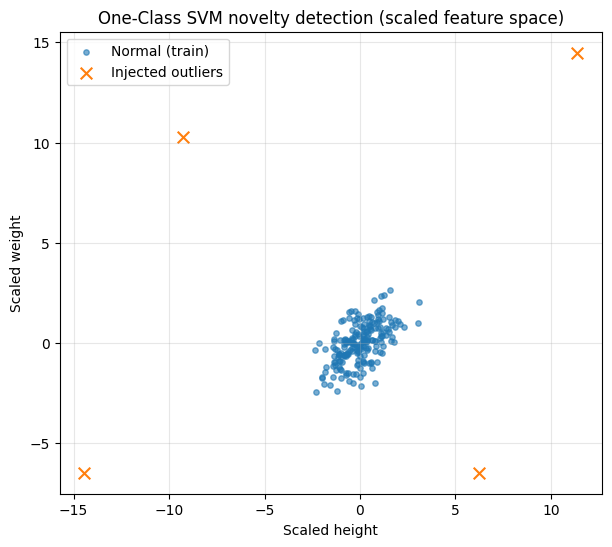

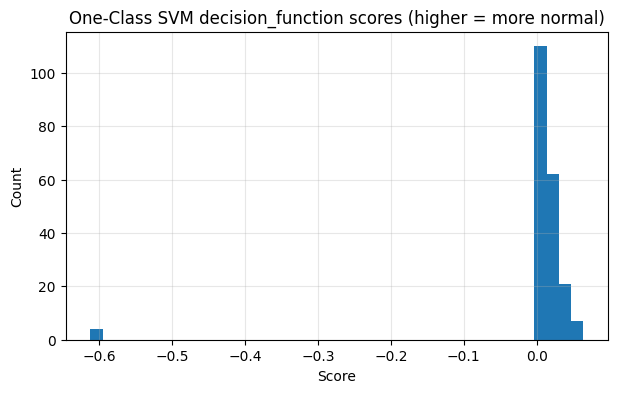

In [17]:
plt.figure(figsize=(7,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=15, alpha=0.6, label="Normal (train)")
plt.scatter(outliers_scaled[:, 0], outliers_scaled[:, 1], s=70, marker="x", label="Injected outliers")
plt.title("One-Class SVM novelty detection (scaled feature space)")
plt.xlabel("Scaled height")
plt.ylabel("Scaled weight")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.hist(scores, bins=40)
plt.title("One-Class SVM decision_function scores (higher = more normal)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


## 9) Case study E — Regression with a tolerance band (SVR)

SVR is used when:

- Relationship is nonlinear (RBF SVR).
- You want a model that ignores small errors (via $\varepsilon$-insensitive loss).
- Dataset size is not enormous (kernel SVR can be slow).

We will use a structured regression dataset: `house-prices.csv`.

We will:

1. Build a preprocessing pipeline (numeric scaling + categorical one-hot).
2. Fit an RBF SVR and a LinearSVR baseline.
3. Compare with metrics: MAE, RMSE, $R^2$.
4. Discuss what $\varepsilon$ means operationally.

### Operational meaning of $\varepsilon$

If predictions inside $\pm \varepsilon$ are effectively acceptable (measurement noise, tolerable deviation),
SVR encodes this preference directly. Increasing $\varepsilon$ makes the model less sensitive to small deviations
and can reduce the number of support vectors.


In [18]:
house_path = DATASETS_ROOT / "Regression" / "house-prices.csv"
house = load_csv(str(house_path))
house.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [19]:
target = "Price"
X = house.drop(columns=[target]).copy()
y = house[target].copy()

categorical_cols = ["Brick", "Neighborhood"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ]
)

svr_rbf = Pipeline(steps=[
    ("prep", preprocess),
    ("svr", SVR(kernel="rbf"))
])

svr_lin = Pipeline(steps=[
    ("prep", preprocess),
    ("svr", LinearSVR(random_state=RANDOM_STATE, max_iter=20000))
])

param_grid = {
    "svr__C": [1, 10, 100],
    "svr__gamma": ["scale", 0.1, 0.01],
    "svr__epsilon": [0.1, 1.0, 5.0],
}
gs = GridSearchCV(svr_rbf, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error", refit=True)
fit_time = time_fit(gs, X_train, y_train)
print("Fit time (GridSearchCV SVR):", fit_time, "sec")
print("Best SVR params:", gs.best_params_)
best_svr = gs.best_estimator_

svr_lin_time = time_fit(svr_lin, X_train, y_train)
print("Fit time (LinearSVR):", svr_lin_time, "sec")

Fit time (GridSearchCV SVR): 2.656364917755127 sec
Best SVR params: {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__gamma': 0.1}
Fit time (LinearSVR): 0.014070749282836914 sec


RBF SVR (tuned)
MAE:  20007.1377
RMSE: 24245.1260
R^2:  0.0411
LinearSVR (baseline)
MAE:  126673.7188
RMSE: 129072.5978
R^2:  -26.1766


C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\LENOVO.PIESC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


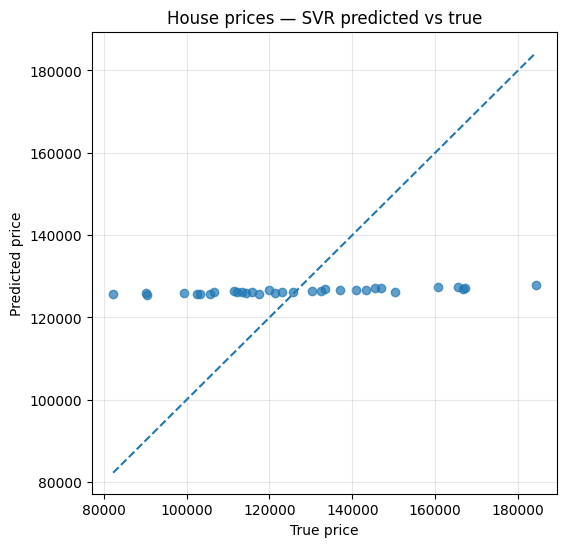

In [20]:
pred_rbf = best_svr.predict(X_test)
pred_lin = svr_lin.predict(X_test)

regression_report(y_test, pred_rbf, title="RBF SVR (tuned)")
regression_report(y_test, pred_lin, title="LinearSVR (baseline)")

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_rbf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("House prices — SVR predicted vs true")
plt.grid(True, alpha=0.3)
plt.show()


## 10) Case study F — Quality classification (Wine quality)

Wine quality is often treated as regression (predict a numeric score), but many real workflows convert it to a decision:

- “High quality” vs “not high quality”
- or “Pass” vs “Fail” in a production pipeline

This is common in quality control and recommendation systems.

We will use `Wine_Quality.csv` and create a binary label:

- Positive: `quality >= 7`
- Negative: `quality <= 6`

### Imbalance note

In many wine datasets, high quality is rarer than medium quality, so imbalance appears.
We will evaluate with PR-AUC and use `class_weight="balanced"`.

### Why try Linear SVM here?

Even though features are numeric and not extremely high-dimensional, linear models can be:

- faster
- easier to debug
- good enough for operational decisions

We will compare:

- LinearSVC
- RBF SVC


In [21]:
wine_path = DATASETS_ROOT / "Classification" / "Wine_Quality.csv"
wine = load_csv(str(wine_path))
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Fit time LinearSVC: 0.017241239547729492 sec
Fit time RBF SVC: 0.6934890747070312 sec
LinearSVC:
              precision    recall  f1-score   support

           0      0.915     0.683     0.782       960
           1      0.402     0.770     0.528       265

    accuracy                          0.702      1225
   macro avg      0.658     0.727     0.655      1225
weighted avg      0.804     0.702     0.727      1225

RBF SVC:
              precision    recall  f1-score   support

           0      0.942     0.767     0.845       960
           1      0.495     0.830     0.621       265

    accuracy                          0.780      1225
   macro avg      0.719     0.798     0.733      1225
weighted avg      0.846     0.780     0.797      1225



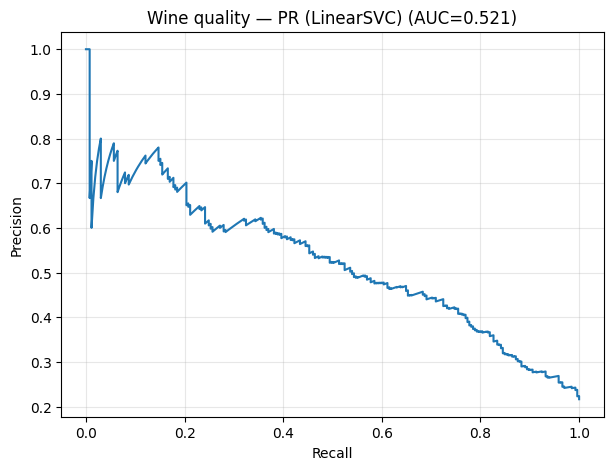

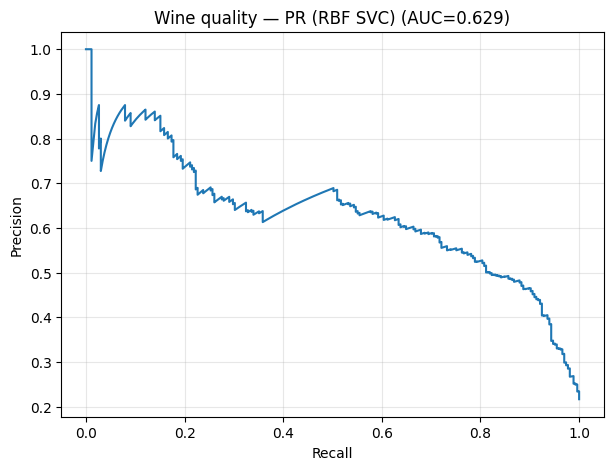

np.float64(0.6293433333236662)

In [22]:
target = "quality"
X = wine.drop(columns=[target]).copy()
y_raw = wine[target].copy()

# Binary label: high quality >= 7
y = (y_raw >= 7).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pipe_lin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=1.0, class_weight="balanced"))
])

pipe_rbf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
])

t_lin = time_fit(pipe_lin, X_train, y_train)
t_rbf = time_fit(pipe_rbf, X_train, y_train)
print("Fit time LinearSVC:", t_lin, "sec")
print("Fit time RBF SVC:", t_rbf, "sec")

score_lin = pipe_lin.decision_function(X_test)
pred_lin = (score_lin >= 0).astype(int)

score_rbf = pipe_rbf.decision_function(X_test)
pred_rbf = (score_rbf >= 0).astype(int)

print("LinearSVC:")
print(classification_report(y_test, pred_lin, digits=3))
print("RBF SVC:")
print(classification_report(y_test, pred_rbf, digits=3))

plot_pr(y_test, score_lin, title="Wine quality — PR (LinearSVC)")
plot_pr(y_test, score_rbf, title="Wine quality — PR (RBF SVC)")


### Debugging which features matter (permutation importance)

SVMs do not provide tree-style feature importance. A common model-agnostic tool is **permutation importance**:

1. Measure baseline performance on a validation set.
2. Shuffle one feature column.
3. Measure performance drop.
4. Larger drop → feature is more important for that metric.

This is expensive but useful for governance and sanity checks.
We will compute it for the linear model.


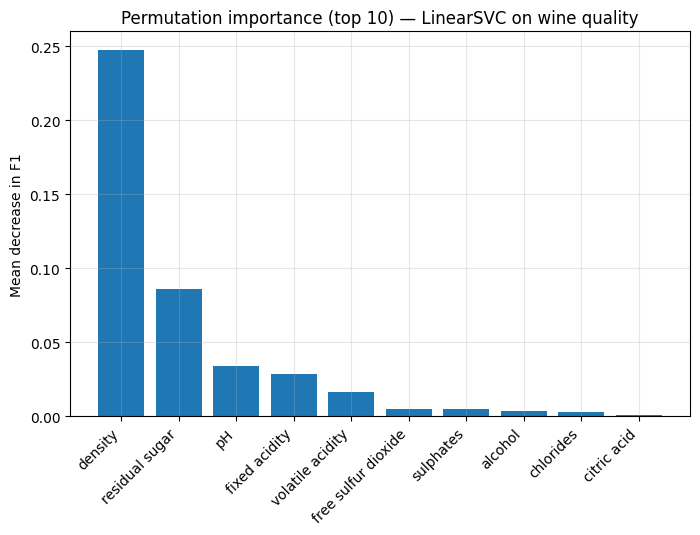

density                0.247734
residual sugar         0.086182
pH                     0.033908
fixed acidity          0.028367
volatile acidity       0.016679
free sulfur dioxide    0.005066
sulphates              0.004676
alcohol                0.003705
chlorides              0.003088
citric acid            0.000888
dtype: float64

In [23]:
result = permutation_importance(
    pipe_lin, X_test, y_test,
    scoring="f1",
    n_repeats=15,
    random_state=RANDOM_STATE
)

imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(imp.index[:10], imp.values[:10])
plt.xticks(rotation=45, ha="right")
plt.title("Permutation importance (top 10) — LinearSVC on wine quality")
plt.ylabel("Mean decrease in F1")
plt.grid(True, alpha=0.3)
plt.show()

imp.head(10)


## 11) Case study G — Multiclass with nonlinear boundaries (Glass)

The glass dataset is a classic multiclass classification task with numeric features and potentially nonlinear decision boundaries.

We will:

- map the string label `Type` to class labels
- build a standardized pipeline
- compare LinearSVC vs RBF SVC
- compute macro-F1 (treat all classes equally)

### Why macro-F1?

If some glass types are rare, accuracy can hide poor minority performance.
Macro-F1 averages F1 across classes equally:

$$
F1_{macro} = \frac{1}{K}\sum_{k=1}^K F1_k.
$$


In [24]:
glass_path = DATASETS_ROOT / "Classification" / "glass.csv"
glass = load_csv(str(glass_path))
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_windows_float_processed
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_windows_float_processed
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_windows_float_processed
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_windows_float_processed
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_windows_float_processed


In [25]:
target = "Type"
X = glass.drop(columns=[target]).copy()
y = glass[target].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pipe_lin = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(C=1.0))
])

pipe_rbf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale"))
])

t_lin = time_fit(pipe_lin, X_train, y_train)
t_rbf = time_fit(pipe_rbf, X_train, y_train)

pred_lin = pipe_lin.predict(X_test)
pred_rbf = pipe_rbf.predict(X_test)

f1_lin = f1_score(y_test, pred_lin, average="macro")
f1_rbf = f1_score(y_test, pred_rbf, average="macro")

print("Fit time LinearSVC:", t_lin, "sec")
print("Fit time RBF SVC:", t_rbf, "sec")
print("Macro-F1 LinearSVC:", f1_lin)
print("Macro-F1 RBF SVC:", f1_rbf)

print("\nClassification report (RBF SVC):")
print(classification_report(y_test, pred_rbf, digits=3))

Fit time LinearSVC: 0.007752180099487305 sec
Fit time RBF SVC: 0.006543159484863281 sec
Macro-F1 LinearSVC: 0.5978863478863479
Macro-F1 RBF SVC: 0.7037037037037037

Classification report (RBF SVC):
                                      precision    recall  f1-score   support

    building_windows_float_processed      0.636     0.778     0.700        18
building_windows_non_float_processed      0.765     0.684     0.722        19
                          containers      1.000     1.000     1.000         3
                           headlamps      1.000     1.000     1.000         8
                           tableware      0.667     1.000     0.800         2
     vehicle_windows_float_processed      0.000     0.000     0.000         4

                            accuracy                          0.741        54
                           macro avg      0.678     0.744     0.704        54
                        weighted avg      0.710     0.741     0.721        54




## 11B) Case study H — Mixed categorical/numeric with multiclass (Stars)

Astronomy-like datasets (or, more generally, scientific catalog datasets) often contain:

- numeric measurements (temperature, luminosity, radius)
- categorical descriptors (color, spectral class)
- a multiclass label (star type)

This mirrors many business datasets where you have both structured measurements and categorical tags.

We will use `stars.csv` (from the Classification folder) and build a multiclass classifier for `Type`.

### Why this is a good SVM application example

- The one-hot categorical space is moderate (not too large).
- Numeric features have different scales (scaling is required).
- Multiclass decisions often benefit from a calibrated score if downstream uses ranking or abstention.

We will:

1. Build a pipeline with numeric scaling and categorical one-hot.
2. Fit `LinearSVC` and compare to `SVC(kernel="rbf")`.
3. Report macro-F1 and show a confusion matrix.

### Practical add-on: abstention (selective prediction)

In some deployments you may prefer to **abstain** on uncertain examples and send them for human review.
With SVM, a simple abstention rule uses the margin (absolute score):

$$
\text{abstain if } |f(x)| < \tau.
$$

- Large $|f(x)|$ means confident separation (far from boundary).
- Small $|f(x)|$ indicates ambiguity (near boundary).

This is not a perfect uncertainty estimate, but it is often a helpful operational heuristic.


In [26]:
stars_path = DATASETS_ROOT / "Classification" / "stars.csv"
stars = load_csv(str(stars_path))
stars.head()

,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,Red Dwarf
1,3042,0.000500,0.1542,16.60,Red,M,Red Dwarf
2,2600,0.000300,0.1020,18.70,Red,M,Red Dwarf
3,2800,0.000200,0.1600,16.65,Red,M,Red Dwarf
4,1939,0.000138,0.1030,20.06,Red,M,Red Dwarf


Fit time LinearSVC: 0.016420602798461914 sec
Fit time RBF SVC: 0.015677452087402344 sec
Macro-F1 LinearSVC: 1.0
Macro-F1 RBF SVC: 0.9832915622389308


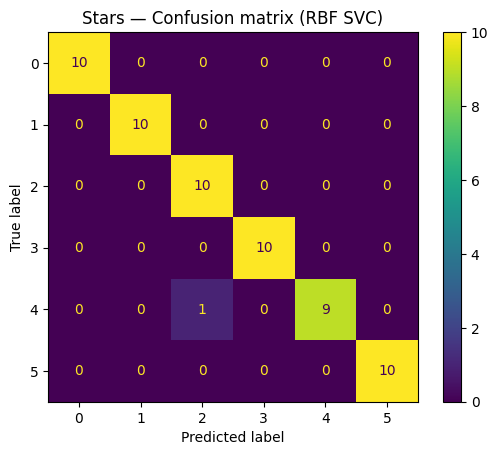


Classification report (RBF SVC):
               precision    recall  f1-score   support

  Brown Dwarf      1.000     1.000     1.000        10
 Hyper Giants      1.000     1.000     1.000        10
Main Sequence      0.909     1.000     0.952        10
    Red Dwarf      1.000     1.000     1.000        10
 Super Giants      1.000     0.900     0.947        10
 White Dwarf       1.000     1.000     1.000        10

     accuracy                          0.983        60
    macro avg      0.985     0.983     0.983        60
 weighted avg      0.985     0.983     0.983        60



In [27]:
target = "Type"
X = stars.drop(columns=[target]).copy()
y = stars[target].astype(str)

categorical_cols = ["Color", "Spectral_Class"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ],
    remainder="drop"
)

pipe_lin = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LinearSVC(C=1.0))
])

pipe_rbf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale"))
])

t_lin = time_fit(pipe_lin, X_train, y_train)
t_rbf = time_fit(pipe_rbf, X_train, y_train)

pred_lin = pipe_lin.predict(X_test)
pred_rbf = pipe_rbf.predict(X_test)

f1_lin = f1_score(y_test, pred_lin, average="macro")
f1_rbf = f1_score(y_test, pred_rbf, average="macro")

print("Fit time LinearSVC:", t_lin, "sec")
print("Fit time RBF SVC:", t_rbf, "sec")
print("Macro-F1 LinearSVC:", f1_lin)
print("Macro-F1 RBF SVC:", f1_rbf)

plot_confusion(y_test, pred_rbf, title="Stars — Confusion matrix (RBF SVC)")
print("\nClassification report (RBF SVC):")
print(classification_report(y_test, pred_rbf, digits=3))


## 12) Practical patterns: calibration, imbalance, latency, monitoring, packaging

### 12.1 Choosing metrics: what “good” means depends on costs

In real systems, model evaluation is not a single metric decision. Examples:

- Medical screening: optimize recall at a safe precision; avoid missed positives.
- Fraud triage: optimize precision at top-k; minimize false alarms that waste analyst time.
- Customer routing: optimize macro-F1 if each class needs adequate service quality.

If costs are known, use expected cost. If costs are unknown, use PR curves and stakeholder feedback.

### 12.2 Calibrated vs uncalibrated: scores are not probabilities

You can use decision scores for ranking, but if you threshold on a probability value,
calibrate first. If you compare probabilities from different models, calibration becomes even more important.

### 12.3 Hyperparameter search patterns that scale

A practical search sequence:

1. Linear baseline (fast): tune $C$ only.
2. Kernel attempt: coarse log grid for $(C,\gamma)$.
3. If too slow: approximate kernels or switch to linear.

Randomized search can be efficient when you have many parameters.
For example:

- sample $\log_{10} C \sim U(a,b)$
- sample $\log_{10} \gamma \sim U(c,d)$

### 12.4 Packaging (train/serve parity)

A reliable SVM deployment exports:

- preprocessing pipeline (imputation, scaling, encoding)
- model
- calibration model (if used)
- metadata: feature list, version, training date, evaluation summary

In Python, you can save a pipeline with `joblib`.
This avoids “forgot to scale in production” incidents.

### 12.5 Monitoring checklist

- Input drift: monitor feature distributions (PSI/KS) relative to training.
- Missingness drift: missing rate changes can break preprocessing assumptions.
- Performance: if labels are available, compute sliding-window metrics.
- Calibration: reliability diagrams on recent data.
- Data quality: out-of-range checks and schema validation.

### 12.6 Security and robustness notes

Even classical models can be attacked:

- Data poisoning: adversary injects mislabeled examples to shift decision boundary.
- Evasion: adversary tweaks features to cross the boundary (e.g., spam text obfuscation).

Mitigations include:

- strict data validation and provenance checks
- robust training protocols
- monitoring for distribution shifts and unusual feature patterns

---

### Optional: approximate RBF kernel with Random Fourier Features

We include a small demo: approximate an RBF kernel with a randomized feature map, then train a linear hinge-loss model.
This can reduce kernel costs while preserving some nonlinearity.


Class counts: {0: 500, 1: 268}
Approx RBF (RFF + linear hinge) accuracy: 0.7447916666666666
              precision    recall  f1-score   support

           0      0.806     0.800     0.803       125
           1      0.632     0.642     0.637        67

    accuracy                          0.745       192
   macro avg      0.719     0.721     0.720       192
weighted avg      0.746     0.745     0.745       192



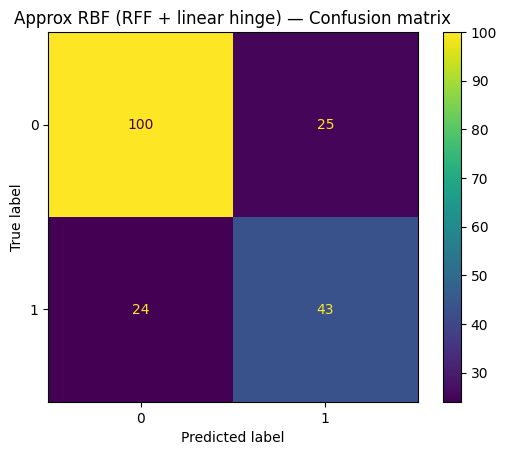

In [28]:
# Optional: a tiny demo of approximate RBF kernel using Random Fourier Features
# (This is a conceptual example; tune n_components for performance/accuracy tradeoffs.)

from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Example assumes diabetes dataset used in this demo
df = load_csv(str(DATASETS_ROOT / "Classification" / "diabetes.csv"))

# ✅ Correct binary label encoding (DO NOT use contains("diabetic"))
y_norm = df["classification"].astype(str).str.strip().str.lower()
y = y_norm.map({"diabetic": 1, "non-diabetic": 0})

# Drop any unexpected labels (safety)
mask = y.notna()
df = df.loc[mask].copy()
y = y.loc[mask].astype(int).values

X = df.drop(columns=["classification"]).astype(float).values

print("Class counts:", pd.Series(y).value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pipe_rff = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("rff", RBFSampler(gamma=0.1, n_components=800, random_state=RANDOM_STATE)),
    ("clf", SGDClassifier(loss="hinge", alpha=1e-4, random_state=RANDOM_STATE))
])

pipe_rff.fit(X_train, y_train)
pred = pipe_rff.predict(X_test)

print("Approx RBF (RFF + linear hinge) accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3, zero_division=0))
plot_confusion(y_test, pred, title="Approx RBF (RFF + linear hinge) — Confusion matrix")



### Saving the pipeline for deployment

In a real repo you typically keep artifacts outside notebooks, but the pattern is:

1. fit pipeline on full training data
2. persist with `joblib.dump`
3. load in a service / batch job and call `.predict` or `.decision_function`

We show the code skeleton below.


In [29]:
import joblib
import pandas as pd

# Example: save the calibrated diabetes model
artifact_path = Path("svm_diabetes_calibrated.joblib")
joblib.dump(calibrated, artifact_path)
print("Saved to:", artifact_path.resolve())

# Example: load later
loaded = joblib.load(artifact_path)

# ✅ Rebuild a DataFrame with the correct number of feature names
# Your error means: X_test has 8 columns, but feature_names has length 1.
n_features = X_test.shape[1] if hasattr(X_test, "shape") else None

# Prefer a correct feature list if available; otherwise generate generic names
if "feature_names" in globals() and isinstance(feature_names, (list, tuple)) and len(feature_names) == n_features:
    cols = list(feature_names)
elif "df" in globals() and hasattr(df, "columns") and "classification" in df.columns:
    # Use df columns excluding target, but only if count matches X_test
    cand = [c for c in df.columns if c != "classification"]
    cols = cand if len(cand) == n_features else [f"x{i}" for i in range(n_features)]
else:
    cols = [f"x{i}" for i in range(n_features)]

# Ensure we pass a DataFrame (to avoid "feature names" warning)
X_test_infer = X_test if hasattr(X_test, "columns") else pd.DataFrame(X_test, columns=cols)

p = loaded.predict_proba(X_test_infer)[:, 1]
print("Loaded model sanity check, ROC-AUC:", roc_auc_score(y_test, p))


Saved to: E:\Machine_Learning_Tutorials\Tutorials\English\Chapter7\svm_diabetes_calibrated.joblib
Loaded model sanity check, ROC-AUC: 0.8013134328358209



## 13) Exercises (practice + mini-project ideas)

### Exercise 1 — Cost-sensitive thresholding (Diabetes)

1. Use the calibrated probabilities `proba` from Case study A.
2. Suppose $C_{FN}=20$ and $C_{FP}=1$.
3. Compute the Bayes threshold $t = \frac{C_{FP}}{C_{FP}+C_{FN}}$.
4. Evaluate confusion matrix at that threshold and compare to threshold 0.5.
5. Plot how recall/precision change as you vary threshold from 0.05 to 0.95.

**Deliverable:** a short cell that prints both confusion matrices and a small curve.

---

### Exercise 2 — Multiclass strategy comparison (Drug200)

Train:

1. `LinearSVC` (OvR)
2. `SVC(kernel="rbf")` (OvO internally)

Compare:

- accuracy
- macro-F1
- training time (rough; wall-clock)

**Question:** when does RBF help, and when does it overfit?

---

### Exercise 3 — Text routing (Consumer complaints)

Make a 3-class model for three products of your choice that have enough narratives.
Use a limited vocabulary `max_features=20000` and compare to `max_features=80000`.

**Question:** how does vocabulary size affect accuracy and latency?

---

### Exercise 4 — One-Class SVM tuning

On the height/weight data, vary $\nu \in \{0.01, 0.02, 0.05, 0.1\}$ and plot number of predicted outliers.
Explain the tradeoff in terms of expected contamination rate.

---

### Exercise 5 — Glass dataset: systematic tuning

Run a grid search for $(C,\gamma)$ on the glass dataset and evaluate macro-F1.
Discuss overfitting risk and the cost of large grids.

---

### Mini-project idea

Pick a dataset from this repo and write a short “production plan”:

- data checks (schema, missingness, leakage risks)
- preprocessing pipeline
- model + hyperparameters
- evaluation metrics aligned to costs
- calibration strategy
- deployment shape (batch vs online)
- monitoring signals
- what could go wrong (failure modes)

This is how SVMs become “real systems,” not only models in a notebook.
